In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
import os
from typing import Annotated, List, TypedDict, Dict, Optional, Union
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.prebuilt import ToolNode


@tool
def create_agent_skill(
        folder_name: str,
        skill_meta_name: str,
        description: str,
        instructions: str,
        scripts: Optional[Dict[str, str]] = None,
        references: Optional[Dict[str, str]] = None,
        assets: Optional[Dict[str, str]] = None
) -> str:
    """
    根据 Agent Skill 规范创建完整的技能文件夹。
    folder_name: 文件夹名称，例如 'data-cleaner'
    skill_meta_name: SKILL.md 内部的 YAML name 字段
    description: 技能描述 (YAML description)
    instructions: SKILL.md 的主体 Markdown 内容
    scripts: 选填，字典格式 {'filename.py': 'content'}
    references: 选填，字典格式 {'doc.md': 'content'}
    assets: 选填，字典格式 {'template.txt': 'content'}
    """
    # 设置基础路径（预设在当前目录的 skills 文件夹下）
    base_path = os.path.join("./skills", folder_name)

    try:
        # 建立主目录
        os.makedirs(base_path, exist_ok=True)

        # 1. 生成 SKILL.md (严格遵守 YAML Frontmatter 格式)
        skill_md_content = f"""---
name: {skill_meta_name}
description: {description}
---

# {skill_meta_name}

{instructions}
"""
        with open(os.path.join(base_path, "SKILL.md"), "w", encoding="utf-8") as f:
            f.write(skill_md_content)

        # 2. 生成子目录与文件
        sub_dirs = {
            "scripts": scripts,
            "references": references,
            "assets": assets
        }

        for dir_name, content_dict in sub_dirs.items():
            if content_dict:
                dir_path = os.path.join(base_path, dir_name)
                os.makedirs(dir_path, exist_ok=True)
                for file_name, content in content_dict.items():
                    with open(os.path.join(dir_path, file_name), "w", encoding="utf-8") as f:
                        f.write(content)

        return f"成功！Agent Skill 已写入至: {base_path}"
    except Exception as e:
        return f"写入失败: {str(e)}"


llm = ChatOpenAI(model="qwen-plus", temperature=0.2)
tools = [create_agent_skill]
llm_with_tools = llm.bind_tools(tools)


def call_model(state: MessagesState):
    """
    Agent 节点：决定下一步是调用工具还是回复用户
    """
    system_prompt = SystemMessage(content=(
        "你是一个专业的 AI Agent 技能架构师。"
        "你的目标是帮助用户设计并实现 'Agent Skills'。"
        "一个标准的 Skill 必须包含 SKILL.md，其中要有 YAML 前导数据 (name, description)。"
        "如果用户的需求涉及程序逻辑，你必须主动编写 Python 脚本并放入 scripts 子目录。"
        "如果涉及模板，放入 assets 子目录。"
        "请确保生成的内容专业、详细且易于 Agent 执行。"
    ))

    # 构造消息列表
    messages = [system_prompt] + state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


workflow = StateGraph(MessagesState)

# 添加处理节点
workflow.add_node("agent", call_model)
workflow.add_node("action", ToolNode(tools))

# 设定入口
workflow.set_entry_point("agent")


# 设定条件逻辑：判断模型是否输出了工具调用指令
def should_continue(state: MessagesState):
    last_message = state['messages'][-1]
    if last_message.tool_calls:
        return "action"
    return END


workflow.add_conditional_edges("agent", should_continue, {END: END, "action": "action"})
workflow.add_edge("action", "agent")

# 编译 Graph
app = workflow.compile()

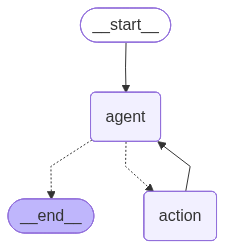

In [3]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
user_query = "我想建立一个技能，可以帮我批量调整图片大小。需要一个 SKILL.md 说明，以及一个使用 Pillow 库的 Python 脚本。"

inputs = {"messages": [HumanMessage(content=user_query)]}

for output in app.stream(inputs, config={"recursion_limit": 10}, stream_mode="values"):
    output["messages"][-1].pretty_print()

--- 启动 Agent Skill 建筑师 ---
用户需求: 我想建立一个技能，可以帮我批量调整图片大小。需要一个 SKILL.md 说明，以及一个使用 Pillow 库的 Python 脚本。

================================ Human Message =================================

我想建立一个技能，可以帮我批量调整图片大小。需要一个 SKILL.md 说明，以及一个使用 Pillow 库的 Python 脚本。
================================== Ai Message ==================================
Tool Calls:
  create_agent_skill (call_b02faae789a74540b50397)
 Call ID: call_b02faae789a74540b50397
  Args:
    folder_name: image-resizer
    skill_meta_name: Image Resizer
    description: 批量调整图片尺寸，支持指定宽高、等比缩放或按比例缩放。
    instructions: ## Image Resizer Skill

### 功能说明
- 批量读取指定目录下的图片（支持 JPG、PNG、WEBP 等常见格式）
- 支持三种调整模式：
  - `exact`: 指定目标宽度和高度（强制拉伸）
  - `fit`: 等比缩放并填充（保持宽高比，填满目标尺寸）
  - `scale`: 按比例缩放（如 0.5 表示缩小为原图 50%）
- 输出图片保存至指定输出目录，保留原始文件名与格式
- 自动跳过非图片文件，并记录处理日志

### 使用方式
运行 `scripts/resizer.py`，需传入以下参数：
- `--input-dir`: 输入图片目录（必填）
- `--output-dir`: 输出目录（必填）
- `--mode`: 调整模式（`exact`, `fit`, `scale`；必填）
- `--width`, `--height`: 用于 `exact` 或 `fit` 模式（整数）
- `--sc